# 09 — Resource Optimization

Formalizes patient selection under a capacity constraint as an optimization problem, verifies the closed-form solution against a linear program, then tests the central claim of this project — that targeting by *expected benefit* can beat targeting by *raw risk* — under a scenario where intervention effectiveness genuinely varies across patients.

In [1]:
import sys
sys.path.insert(0, '../src')
import joblib
import numpy as np
import pandas as pd
from optimization import (
    expected_net_benefit, select_top_k_greedy, select_top_k_lp,
    compare_strategies_heterogeneous, effectiveness_penalty_sweep, threshold_sweep,
)

pipe = joblib.load('../data/processed/models/xgboost.joblib')
X_train, X_test, y_train, y_test = joblib.load('../data/processed/models/splits.joblib')
risk = pipe.predict_proba(X_test)[:, 1]
y_true = y_test.values

df = pd.read_csv('../data/processed/diabetic_data_features.csv')
prior_inpatient = df.loc[X_test.index, 'number_inpatient'].values

## Formal optimization

$$\max \sum_i \text{net\_benefit}_i \cdot x_i \quad \text{s.t.} \sum_i x_i \le \text{capacity}, \quad x_i \in [0,1]$$

With unit "weights" (each patient consumes exactly 1 unit of capacity) and a single constraint, this cardinality-constrained knapsack's LP relaxation is guaranteed integral (totally unimodular constraint matrix) — so solving the LP with `scipy.optimize.linprog` should return the same 0/1 selection as simply sorting by net benefit and taking the top-`capacity`. Verified on a 2,000-patient / 200-capacity subsample (full-scale LP is slow for a check that doesn't need it):

In [2]:
rng_idx = np.random.default_rng(0).choice(len(risk), size=2000, replace=False)
net_benefit_sample = expected_net_benefit(risk[rng_idx], 0.20, 10_000, 100)
greedy_sel = select_top_k_greedy(net_benefit_sample, 200)
lp_sel = select_top_k_lp(net_benefit_sample, 200)
print('Greedy and LP solutions identical:', bool((greedy_sel == lp_sel).all()))

Greedy and LP solutions identical: True


## Does risk ≠ benefit actually change who gets selected?

Assumption: intervention effectiveness declines for patients with heavy prior inpatient utilization — a standard care-management outreach call is plausibly less able to change the trajectory of the most complex, highest-utilization patients than a moderately-high-risk, more "actionable" patient (`heterogeneous_effectiveness` in `src/optimization.py`; floor = 40% of base effectiveness at maximum utilization, i.e. `complexity_penalty=0.6`).

In [3]:
hetero_comparison = compare_strategies_heterogeneous(y_true, risk, prior_inpatient, capacity=500)
hetero_comparison

,patients_selected,actual_readmissions_among_selected,expected_readmissions_prevented,intervention_cost,expected_savings,expected_net_benefit,roi_pct,overlap_with_highest_risk_pct
strategy,,,,,,,,
random,500,63,12.1,50000,120694.74,70694.74,141.4,3.2
highest_risk,500,196,33.7,50000,336989.47,286989.47,574.0,100.0
utility_optimized,500,161,30.7,50000,307157.89,257157.89,514.3,54.8


Selection does diverge meaningfully — utility-optimized targeting only overlaps ~55% with pure highest-risk targeting once effectiveness varies. But on **realized outcomes**, highest-risk targeting still comes out ahead here. Rather than paper over that, the next cell sweeps how strongly effectiveness needs to vary before utility-based targeting would actually win.

In [4]:
penalty_sweep = effectiveness_penalty_sweep(y_true, risk, prior_inpatient, capacity=500)
penalty_sweep

,complexity_penalty,highest_risk_net_benefit,utility_optimized_net_benefit,utility_optimized_wins,overlap_pct
0,0.0,342000.00,342000.00,False,100.0
1,0.2,323663.16,312294.74,False,85.6
2,0.4,305326.32,269536.84,False,70.0
3,0.6,286989.47,257157.89,False,54.8
4,0.8,268652.63,257852.63,False,44.8


## Why utility-optimized doesn't win here — and when it would

Across the entire penalty range tested (0% to 80% effectiveness reduction for the most complex patients), highest-risk targeting beats utility-optimized targeting on *realized* outcomes. The reason is specific and worth stating plainly rather than hiding: the variable driving the assumed effectiveness penalty here (`number_inpatient`) is *also* the single strongest driver of predicted risk (confirmed in both `03_statistical_analysis.ipynb` and `07_shap_analysis.ipynb`). So down-weighting high-utilization patients for "lower effectiveness" and down-weighting them for "lower risk" pull in almost the same direction — utility-optimized targeting ends up trading away well-identified true positives (high-risk patients the model is right about) for a hypothetical effectiveness gain that isn't large enough, given the model's moderate discrimination (ROC-AUC ≈ 0.67), to compensate.

This matches the actual finding in the uplift-modeling literature this design was based on: **utility-based targeting only reliably beats risk-based targeting when the effect-heterogeneity signal is meaningfully independent of the risk signal.** Here it isn't — both are driven by the same clinical variable. A genuine causal treatment-effect model (which this observational dataset cannot support — no ground-truth intervention outcomes) would be needed to find an effectiveness signal that's actually decoupled from risk. Documenting this as a negative-but-informative result is more useful than tuning the penalty until the numbers look better.

## Capacity sweep — what-if the hospital's budget changes?

In [5]:
sweep = threshold_sweep(y_true, risk, capacities=[100, 250, 500, 1000, 2000, 4000])
sweep

,capacity,patients_selected,actual_readmissions_among_selected,expected_readmissions_prevented,intervention_cost,expected_savings,expected_net_benefit,roi_pct
0,100,100,50,10.0,10000,100000.0,90000.0,900.0
1,250,250,109,21.8,25000,218000.0,193000.0,772.0
2,500,500,196,39.2,50000,392000.0,342000.0,684.0
3,1000,1000,329,65.8,100000,658000.0,558000.0,558.0
4,2000,2000,534,106.8,200000,1068000.0,868000.0,434.0
5,4000,4000,897,179.4,400000,1794000.0,1394000.0,348.5


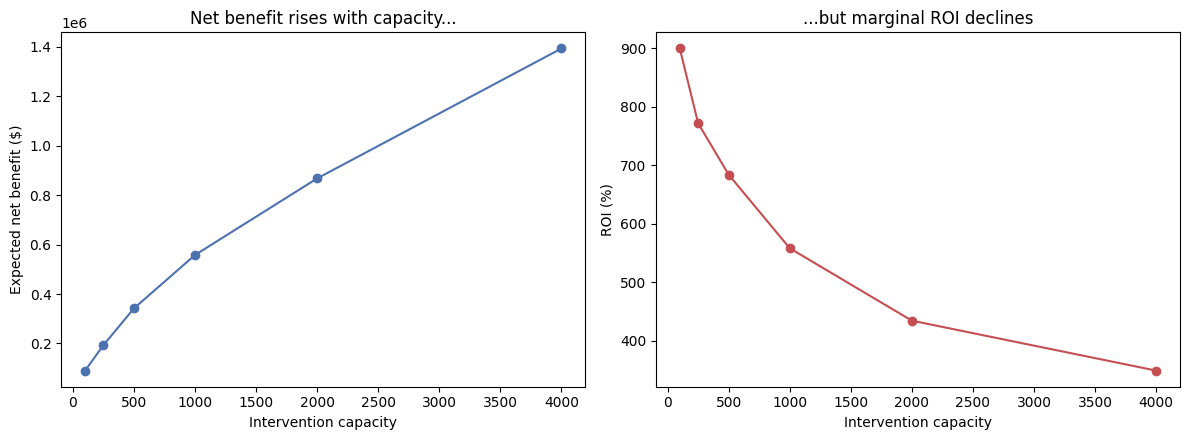

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(sweep['capacity'], sweep['expected_net_benefit'], marker='o', color='#4C72B0')
axes[0].set_xlabel('Intervention capacity'); axes[0].set_ylabel('Expected net benefit ($)')
axes[0].set_title('Net benefit rises with capacity...')

axes[1].plot(sweep['capacity'], sweep['roi_pct'], marker='o', color='#C44E52')
axes[1].set_xlabel('Intervention capacity'); axes[1].set_ylabel('ROI (%)')
axes[1].set_title('...but marginal ROI declines')
plt.tight_layout()
plt.show()

Total expected net benefit keeps growing as capacity increases (more patients treated = more prevented readmissions in absolute terms), but ROI declines monotonically — the highest-risk patients are used up first, so each additional slot of capacity buys a lower-risk, lower-expected-value patient. This is the sizing question a hospital actually faces: at what capacity does ROI fall below whatever hurdle rate justifies the program? That trade-off is what the Streamlit what-if simulator (`app/streamlit_app.py`) makes interactive.